In [113]:
from torchvision import datasets
from torchvision import transforms

from torch.utils.tensorboard import SummaryWriter

import torch
import torch.nn as nn


from matplotlib import pyplot as plt
from tqdm import tqdm

from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd

import os

In [114]:
print('torch version:', torch.__version__)
print('CUDA version:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
print('cuDNN version:', torch.backends.cudnn.version())
print('cuDNN enabled:', torch.backends.cudnn.enabled)
print('GPU name:', torch.cuda.get_device_name(0))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

torch version: 2.10.0+cu130
CUDA version: 13.0
CUDA available: True
cuDNN version: 91200
cuDNN enabled: True
GPU name: NVIDIA GeForce RTX 5060
Using device: cuda


In [115]:
# 激活函数
# 激活函数是神经网络中的非线性函数，用于引入非线性特征，使得神经网络能够学习复杂的模式和关系。
# 常见的激活函数包括ReLU、Sigmoid、Tanh等。
# ReLU函数：f(x) = max(0, x)，当输入大于0时输出输入值，否则输出0。
# Sigmoid函数：f(x) = 1 / (1 + exp(-x))，将输入值压缩到0和1之间。
# Tanh函数：f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))，将输入值压缩到-1和1之间。

# SoftMax 函数
# 函数将一个向量转换为一个概率分布，使得输出的每个元素都在0和1之间，并且所有元素的和为1。
# 公式：softmax(x_i) = exp(x_i) / sum(exp(x_j))，其中x_i是输入向量的第i个元素，x_j是输入向量的所有元素。

# 交叉熵损失函数
# 交叉熵损失函数用于衡量两个概率分布之间的差异，常用于分类问题中。
# 公式：cross_entropy(p, q) = -sum(p_i * log(q_i))，其中p是实际分布，q是预测分布，p_i和q_i分别是第i个元素。

In [116]:
# sample case

def compute_dataset_mean_std(dataset, batch_size=1024, num_workers=0):
    """计算图像数据集每个通道的均值和标准差。"""
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    channel_sum = 0.0
    channel_sum_sq = 0.0
    num_batches = 0

    for data, _ in loader:
        # data shape: [B, C, H, W]
        channel_sum += data.mean(dim=[0, 2, 3])
        channel_sum_sq += (data ** 2).mean(dim=[0, 2, 3])
        num_batches += 1

    mean = channel_sum / num_batches
    std = (channel_sum_sq / num_batches - mean ** 2).sqrt()

    return tuple(mean.tolist()), tuple(std.tolist())

# 先用仅 ToTensor 的训练集计算统计值（避免数据泄露）
raw_train_ds = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
 )

fmnist_mean, fmnist_std = compute_dataset_mean_std(raw_train_ds)
print('FashionMNIST mean:', fmnist_mean)
print('FashionMNIST std:', fmnist_std)

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为PyTorch张量，并将像素值归一化到[0, 1]范围内
    transforms.Normalize(
        mean=fmnist_mean,
        std=fmnist_std
    ),  # 对图像进行标准化处理
])

# FashionMNIST数据集是一个包含10个类别的图像数据集，每个类别包含6000张训练图像和1000张测试图像。
# 每张图像是28x28像素的灰度图。
# 加载训练数据集
train_ds = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

# 加载验证数据集
val_ds = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

FashionMNIST mean: (0.28610852360725403,)
FashionMNIST std: (0.3530576825141907,)


图像形状: torch.Size([1, 28, 28])
标签: 9
img: tensor([[[-8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01],
         [-8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01, -8.1037e-01],
         [-8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01, -8.1037e-01,
          -8.1037e-01, -8.1037e-01

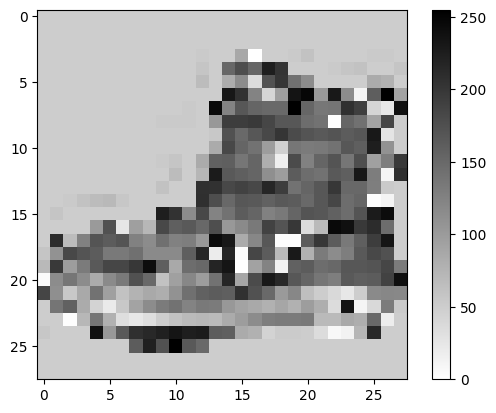

In [117]:
img, label = train_ds[0]
print('图像形状:', img.shape)
print('标签:', label)
print('img:', img)
plt.imshow(transforms.ToPILImage()(img), cmap='binary')
plt.colorbar()
plt.show()

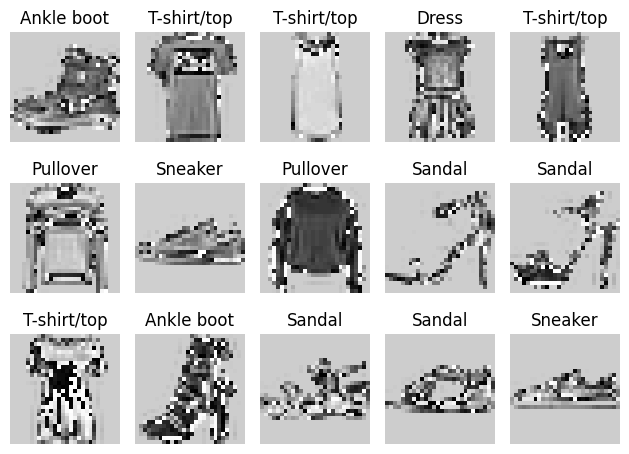

In [118]:
# 可视化前15张图像
for i in range(15):
    img, label = train_ds[i]
    plt.subplot(3, 5, i + 1)
    plt.imshow(transforms.ToPILImage()(img), cmap='binary')
    plt.title(train_ds.classes[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [119]:
# 创建数据加载器
# DateLoader是PyTorch中用于加载数据的工具，它提供了批量加载、数据打乱和多线程加载等功能。
# batch_size参数指定每个批次的样本数量，shuffle参数指定是否在每个epoch开始时打乱数据。
# num_workers参数指定用于数据加载的子进程数量，默认为0表示在主进程中加载数据。
# pin_memory参数指定是否将数据加载到固定内存中，这对于使用GPU训练模型时可以提高性能。
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=32, shuffle=True, num_workers=0
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=32, shuffle=False, num_workers=0
)

In [120]:
for data, label in train_loader:
    print('数据批次形状:', data.shape)
    print('标签批次形状:', label.shape)
    break

数据批次形状: torch.Size([32, 1, 28, 28])
标签批次形状: torch.Size([32])


In [121]:
# 参数：在神经网络中，参数是指模型中需要学习的权重和偏置等数值，这些参数会在训练过程中通过反向传播算法进行更新，以最小化损失函数。
# 超参数：在训练神经网络时需要手动设置的参数，如学习率、批次大小、迭代次数等。

# 定义神经网络模型
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()  # 调用父类的构造函数，初始化神经网络模型

        self.flatten = nn.Flatten()  # 将输入的图像数据从二维展平为一维，以便输入到全连接层中

        self.linear_relu_stack = nn.Sequential(  # 定义一个顺序容器，包含多个层和激活函数
            # w 的初始分布是均匀分布，范围是[-sqrt(k), sqrt(k)]，其中k是输入特征的数量。
            nn.Linear(28*28, 512),  # 定义一个全连接层，将输入的784维特征映射到512维特征
            nn.ReLU(),  # 定义一个ReLU激活函数，增加模型的非线性能力
            nn.Linear(512, 256),  # 定义一个全连接层，将输入的512维特征映射到256维特征
            nn.ReLU(),  # 定义一个ReLU激活函数，增加模型的非线性能力
            nn.Linear(256, 10)  # 定义最后一个全连接层，将输入的256维特征映射到10维特征，对应10个类别的输出
        )

    def forward(self, x):
        # x.shape: [batch_size, 1(通道数), 28, 28] -> [batch_size, 28*28]
        x = self.flatten(x)  # 将输入的图像数据展平为一维

        # 将展平后的输入数据通过定义的顺序容器进行前向传播，得到输出的logits（未经过SoftMax函数处理的原始输出）
        logits = self.linear_relu_stack(x)

        return logits


# 创建神经网络模型实例
model = NeuralNetwork()

In [122]:
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [123]:
# 计算模型的总参数量
# model.parameters()返回模型中所有可训练参数的迭代器，每个参数都是一个张量。
# p.numel()计算每个参数张量中的元素数量，np.sum()将所有参数的元素数量相加，得到模型的总参数量。

for name, param in model.named_parameters():
    print(f'层名称: {name}, 参数形状: {param.shape}, 参数数量: {param.numel()}')

print('模型总参数量:', np.sum([p.numel() for p in model.parameters()]))

层名称: linear_relu_stack.0.weight, 参数形状: torch.Size([512, 784]), 参数数量: 401408
层名称: linear_relu_stack.0.bias, 参数形状: torch.Size([512]), 参数数量: 512
层名称: linear_relu_stack.2.weight, 参数形状: torch.Size([256, 512]), 参数数量: 131072
层名称: linear_relu_stack.2.bias, 参数形状: torch.Size([256]), 参数数量: 256
层名称: linear_relu_stack.4.weight, 参数形状: torch.Size([10, 256]), 参数数量: 2560
层名称: linear_relu_stack.4.bias, 参数形状: torch.Size([10]), 参数数量: 10
模型总参数量: 535818


In [124]:
# 检查forward方法
for data, label in train_loader:
    output = model(data)  # 将输入数据传递给模型，得到输出的logits
    print('输出形状:', output.shape)  # 输出的形状应该是[batch_size, 10]，对应10个类别的输出
    break

输出形状: torch.Size([32, 10])


In [125]:
# 定义损失函数和优化器

# 交叉熵损失函数适用于多分类问题，它将模型的输出（logits）与实际标签进行比较，计算损失值。
# 内部计算SoftMax函数来将logits转换为概率分布，并计算了实际标签与预测概率分布之间的交叉熵损失。
loss_fn = nn.CrossEntropyLoss()

# 定义优化器，使用随机梯度下降算法
# lr是学习率，控制模型参数更新的步长，过大可能导致训练不稳定，过小可能导致训练过慢。
# momentum是动量参数，帮助加速SGD在相关方向上的收敛，并抑制震荡。
# w 的更新规则是：w = w - lr * dw + momentum * v，其中dw是当前梯度，v是之前的更新值。
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [126]:
@torch.no_grad()  # 在评估模型时，我们不需要计算梯度，因此使用@torch.no_grad()装饰器来禁用梯度计算，以节省内存和加速计算。
def evaluate(model, dataloader, loss_fn):
    loss_list = []  # 存储每个批次的损失值
    pred_list = []  # 存储每个批次的预测标签
    label_list = []  # 存储每个批次的实际标签

    for data, label in dataloader:
        data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
        label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

        logits = model(data)  # 将输入数据传递给模型，得到输出的logits
        loss = loss_fn(logits, label)  # 计算当前批次的损失值

        # item()方法将单元素张量转换为Python数值，方便存储和计算。
        loss_list.append(loss.item())  # 将当前批次的损失值添加到列表中

        # 获取模型预测的类别标签, argmax函数返回沿指定维度最大值的索引，这里dim=1表示在类别维度上取最大值的索引，即预测的类别标签
        pred = logits.argmax(dim=1)
        # 将预测标签移动到CPU并转换为NumPy数组，添加到列表中
        pred_list.extend(pred.cpu().numpy().tolist())

        # 将实际标签移动到CPU并转换为NumPy数组，添加到列表中
        label_list.extend(label.cpu().numpy().tolist())

    # 计算整体的准确率，使用sklearn的accuracy_score函数比较预测标签和实际标签
    accuracy = accuracy_score(pred_list, label_list)

    # 返回平均损失值和准确率
    return np.mean(loss_list), accuracy

In [131]:
def train(model, train_loader, val_loader, loss_fn, optimizer, epochs=20, eval_interval=500):
    record_dict = {
        'train': [],
        'val': []
    }

    global_step = 0  # 定义一个全局步骤计数器，用于跟踪训练过程中的总步骤数
    model.train()  # 将模型设置为训练模式，启用dropout和batch normalization等训练特定的行为

    with tqdm(total=epochs * len(train_loader), desc="Training") as pbar:  # 使用tqdm库创建一个进度条，显示训练的进度
        for epoch in range(epochs):  # 训练指定的轮数
            for data, label in train_loader:
                data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
                label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

                optimizer.zero_grad()  # 梯度清零，准备进行反向传播

                logits = model(data)  # 前向传播，计算模型的输出logits

                loss = loss_fn(logits, label)  # 计算损失值，比较模型的输出logits与实际标签

                loss.backward()  # 反向传播，计算梯度

                optimizer.step()  # 更新模型参数，使用计算得到的梯度

                pred = logits.argmax(dim=1)  # 获取模型预测的类别标签

                # 计算当前批次的准确率
                acc = accuracy_score(pred.cpu().numpy(), label.cpu().numpy())

                loss = loss.item()  # 将损失值从张量转换为Python数值

                # 记录当前批次的损失值和准确率
                record_dict['train'].append({
                    'step': global_step,
                    'loss': loss,
                    'accuracy': acc
                })

                # 每隔eval_interval步进行一次评估，计算验证集上的损失值和准确率，并记录下来
                if global_step % eval_interval == 0:
                    model.eval()  # 将模型设置为评估模式，禁用dropout和batch normalization等训练特定的行为
                    val_loss, val_acc = evaluate(
                        model, val_loader, loss_fn)  # 在验证集上评估模型，得到损失值和准确率
                    record_dict['val'].append({
                        'step': global_step,
                        'loss': val_loss,
                        'accuracy': val_acc
                    })
                    model.train()  # 将模型切换回训练模式，继续训练

                global_step += 1  # 更新全局步骤计数器
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({'epoch': epoch})  # 在进度条上显示当前的epoch信息

    return record_dict

In [132]:
model = model.to(device)  # 将模型移动到指定设备（CPU或GPU）
record_dict = train(model, train_loader, val_loader, loss_fn, optimizer)

Training: 100%|██████████| 37500/37500 [04:28<00:00, 139.66it/s, epoch=19]


In [133]:
record_dict['train'][-5:]

[{'step': 37495, 'loss': 0.24841085076332092, 'accuracy': 0.9375},
 {'step': 37496, 'loss': 0.17201189696788788, 'accuracy': 0.96875},
 {'step': 37497, 'loss': 0.31888246536254883, 'accuracy': 0.90625},
 {'step': 37498, 'loss': 0.26999470591545105, 'accuracy': 0.9375},
 {'step': 37499, 'loss': 0.1442355513572693, 'accuracy': 0.9375}]

In [134]:
record_dict['val']

[{'step': 0, 'loss': np.float64(2.302557527828521), 'accuracy': 0.1217},
 {'step': 500, 'loss': np.float64(0.6837942779254609), 'accuracy': 0.7425},
 {'step': 1000, 'loss': np.float64(0.557158098434107), 'accuracy': 0.8},
 {'step': 1500, 'loss': np.float64(0.5113691060592572), 'accuracy': 0.8137},
 {'step': 2000, 'loss': np.float64(0.48270327500261057), 'accuracy': 0.8237},
 {'step': 2500, 'loss': np.float64(0.4725942551708831), 'accuracy': 0.827},
 {'step': 3000, 'loss': np.float64(0.44918218402626414), 'accuracy': 0.8368},
 {'step': 3500, 'loss': np.float64(0.4397083802725941), 'accuracy': 0.8406},
 {'step': 4000, 'loss': np.float64(0.4316192347401628), 'accuracy': 0.8418},
 {'step': 4500, 'loss': np.float64(0.42825026186510395), 'accuracy': 0.8448},
 {'step': 5000, 'loss': np.float64(0.41830173061012077), 'accuracy': 0.8495},
 {'step': 5500, 'loss': np.float64(0.40417509568861115), 'accuracy': 0.8553},
 {'step': 6000, 'loss': np.float64(0.4048907709197876), 'accuracy': 0.853},
 {'st

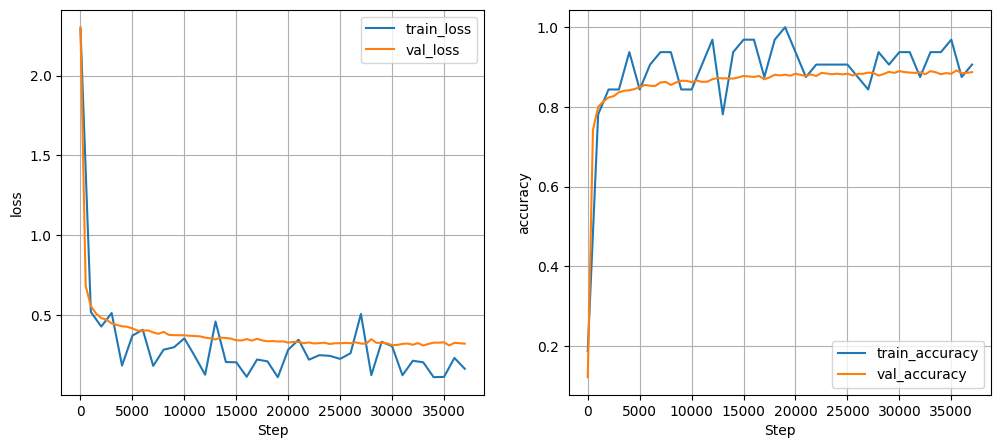

In [135]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx, item in enumerate(['loss', 'accuracy']):
    ax = axs[idx]
    ax.plot([x['step'] for x in record_dict['train']][::1000],
            [x[item] for x in record_dict['train']][::1000], label='train_' + item)
    ax.plot([x['step'] for x in record_dict['val']],
            [x[item] for x in record_dict['val']], label='val_' + item)
    ax.set_xlabel('Step')
    ax.set_ylabel(item)
    ax.grid()
    ax.legend()

In [ ]:
# # 可视化
# class TensorboardCallback:
#     def __init__(self, log_dir):
#         self.writer = torch.utils.tensorboard.SummaryWriter(log_dir)

#     def on_epoch_end(self, epoch, logs=None):
#         if logs is not None:
#             self.writer.add_scalar('Loss/train', logs['train_loss'], epoch)
#             self.writer.add_scalar('Accuracy/train', logs['train_acc'], epoch)
#             self.writer.add_scalar('Loss/val', logs['val_loss'], epoch)
#             self.writer.add_scalar('Accuracy/val', logs['val_acc'], epoch)

#     def close(self):
#         self.writer.close()

In [151]:
# 保存模型检查点
class CheckpointsCallback:
    def __init__(self, save_path, save_step=100, save_best_only=True):
        self.save_step = save_step
        self.save_path = save_path
        self.save_best_only = save_best_only
        self.best_metric = -1

        if not os.path.exists(save_path):
            os.makedirs(save_path)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return
        if self.save_best_only:
            assert metric is not None, "metric must be provided when save_best_only is True"
            if metric >= self.best_metric:
                self.best_metric = metric
                torch.save(state_dict, os.path.join(
                    self.save_path, f'best_model.ckpt'))
        else:
            torch.save(state_dict, os.path.join(
                self.save_path, f'model_step_{step}.ckpt'))

In [ ]:
# 早停
class EarlyStopCallback:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.wait = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            self.wait = 0
        else:
            self.wait += 1
        return self.wait >= self.patience

In [147]:
# 训练函数，增加回调函数参数
def train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20,
    eval_interval=500,
    checkpoints_callback=None,
    earlystop_callback=None,
    tensorboard_callback=None
):

    record_dict = {
        'train': [],
        'val': []
    }

    global_step = 0  # 定义一个全局步骤计数器，用于跟踪训练过程中的总步骤数
    model.train()  # 将模型设置为训练模式，启用dropout和batch normalization等训练特定的行为

    with tqdm(total=epochs * len(train_loader), desc="Training with callbacks") as pbar:  # 使用tqdm库创建一个进度条，显示训练的进度
        for epoch in range(epochs):  # 训练指定的轮数
            for data, label in train_loader:
                data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
                label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

                optimizer.zero_grad()  # 梯度清零，准备进行反向传播

                logits = model(data)  # 前向传播，计算模型的输出logits

                loss = loss_fn(logits, label)  # 计算损失值，比较模型的输出logits与实际标签

                loss.backward()  # 反向传播，计算梯度

                optimizer.step()  # 更新模型参数，使用计算得到的梯度

                pred = logits.argmax(dim=1)  # 获取模型预测的类别标签

                # 计算当前批次的准确率
                acc = accuracy_score(pred.cpu().numpy(), label.cpu().numpy())

                loss = loss.item()  # 将损失值从张量转换为Python数值

                # 记录当前批次的损失值和准确率
                record_dict['train'].append({
                    'step': global_step,
                    'loss': loss,
                    'accuracy': acc
                })

                # 每隔eval_interval步进行一次评估，计算验证集上的损失值和准确率，并记录下来
                if global_step % eval_interval == 0:
                    model.eval()  # 将模型设置为评估模式，禁用dropout和batch normalization等训练特定的行为
                    val_loss, val_acc = evaluate(
                        model, val_loader, loss_fn)  # 在验证集上评估模型，得到损失值和准确率
                    record_dict['val'].append({
                        'step': global_step,
                        'loss': val_loss,
                        'accuracy': val_acc
                    })
                    model.train()  # 将模型切换回训练模式，继续训练

                    # 调用回调函数
                    if checkpoints_callback is not None:
                        checkpoints_callback(
                            step=global_step,
                            state_dict=model.state_dict(),
                            metric=val_acc
                        )
                    if earlystop_callback is not None and earlystop_callback(val_acc):
                        print(
                            f"Early stop at epoch {epoch} / step {global_step}, val_acc: {val_acc:.4f}")
                        return record_dict

                global_step += 1  # 更新全局步骤计数器
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({'epoch': epoch})  # 在进度条上显示当前的epoch信息

    return record_dict

In [158]:
# 带有回调函数的训练
model = NeuralNetwork().to(device)

ckpt_callback = CheckpointsCallback(
    save_path='checkpoints', save_best_only=True)
earlystop_callback = EarlyStopCallback()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=100,
    eval_interval=1000,
    checkpoints_callback=ckpt_callback,
    earlystop_callback=earlystop_callback
)

Training with callbacks:   8%|▊         | 15000/187500 [01:32<17:39, 162.79it/s, epoch=7]

Early stop at epoch 8 / step 15000, val_acc: 0.8748


In [159]:
# 加载模型
model = NeuralNetwork().to(device)  # 创建一个新的神经网络模型实例，并将其移动到指定设备（CPU或GPU）
model.eval()

loss, acc = evaluate(model, val_loader, loss_fn)  # 在验证集上评估模型，得到损失值和准确率
print(f'初始随机参数模型在验证集上的损失值: {loss:.4f}, 准确率: {acc:.4f}')

# 从保存的检查点文件中加载模型参数，更新当前模型的状态字典
model.load_state_dict(torch.load('checkpoints/best_model.ckpt'))
model.eval()  # 将模型设置为评估模式
loss, acc = evaluate(model, val_loader, loss_fn)  # 在验证集上评估模型，得到损失值和准确率
print(f'加载检查点后模型在验证集上的损失值: {loss:.4f}, 准确率: {acc:.4f}')

初始随机参数模型在验证集上的损失值: 2.3171, 准确率: 0.1007
加载检查点后模型在验证集上的损失值: 0.3465, 准确率: 0.8752
